In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/imdb_clean.csv")

display(df.head())

,name,year,duration,genre,rating,votes,director,actor_1,actor_2,actor_3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.info())

Shape: (15503, 10)

Columns:
['name', 'year', 'duration', 'genre', 'rating', 'votes', 'director', 'actor_1', 'actor_2', 'actor_3']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15503 entries, 0 to 15502
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      15503 non-null  object 
 1   year      14976 non-null  object 
 2   duration  7239 non-null   object 
 3   genre     13627 non-null  object 
 4   rating    7919 non-null   float64
 5   votes     7920 non-null   object 
 6   director  14979 non-null  object 
 7   actor_1   13888 non-null  object 
 8   actor_2   13122 non-null  object 
 9   actor_3   12363 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


None

In [4]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().sum() / len(df) * 100, 2)
}).sort_values("Percentage", ascending=False)

display(missing)

,Missing Values,Percentage
duration,8264,53.31
rating,7584,48.92
votes,7583,48.91
actor_3,3140,20.25
actor_2,2381,15.36
genre,1876,12.10
actor_1,1615,10.42
year,527,3.40
director,524,3.38
name,0,0.00


In [5]:
df_eda = df.copy()

# Clean year
df_eda["year"] = df_eda["year"].astype(str).str.extract(r"(\d{4})")
df_eda["year"] = pd.to_numeric(df_eda["year"], errors="coerce")

# Clean duration
df_eda["duration"] = df_eda["duration"].astype(str).str.extract(r"(\d+)")
df_eda["duration"] = pd.to_numeric(df_eda["duration"], errors="coerce")

# Clean votes
df_eda["votes"] = (
    df_eda["votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")
)

df_eda["votes"] = pd.to_numeric(df_eda["votes"], errors="coerce")

# Clean rating
df_eda["rating"] = pd.to_numeric(df_eda["rating"], errors="coerce")

display(df_eda.head())

,name,year,duration,genre,rating,votes,director,actor_1,actor_2,actor_3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,90.0,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,105.0,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


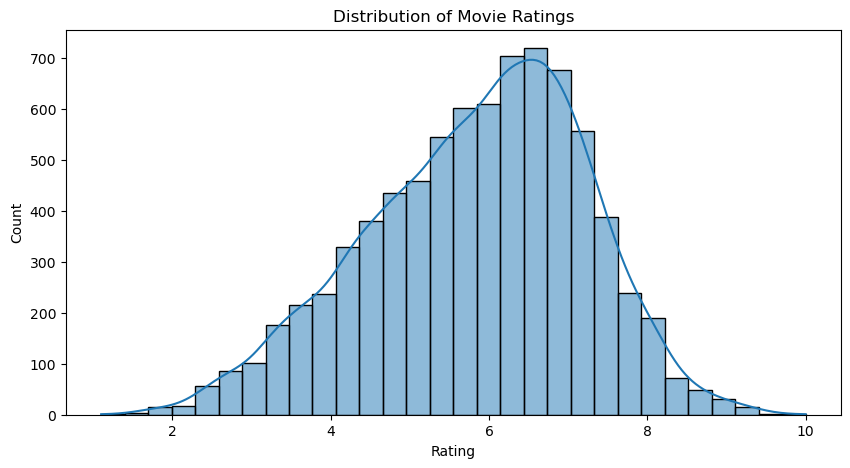

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eda["rating"], bins=30, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

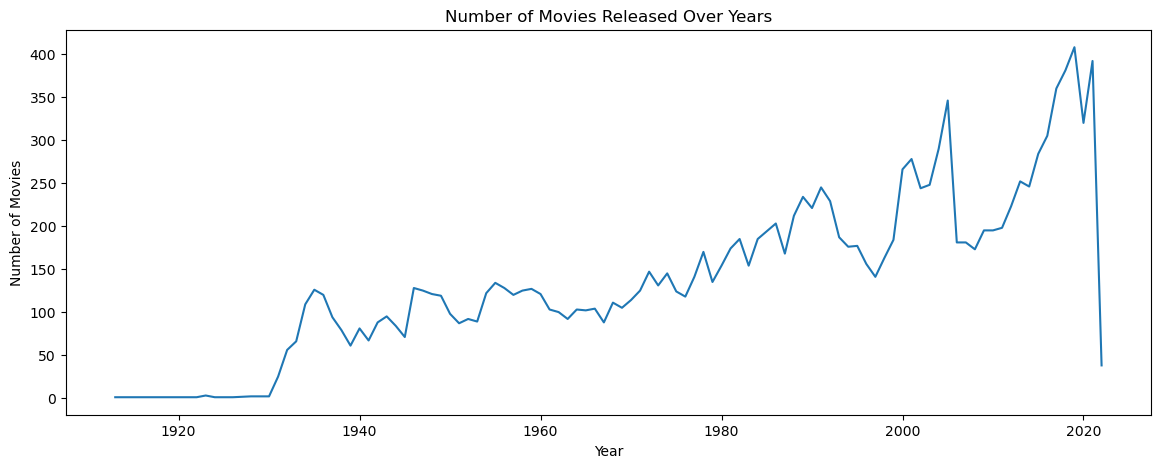

In [7]:
plt.figure(figsize=(14, 5))
df_eda["year"].value_counts().sort_index().plot()
plt.title("Number of Movies Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

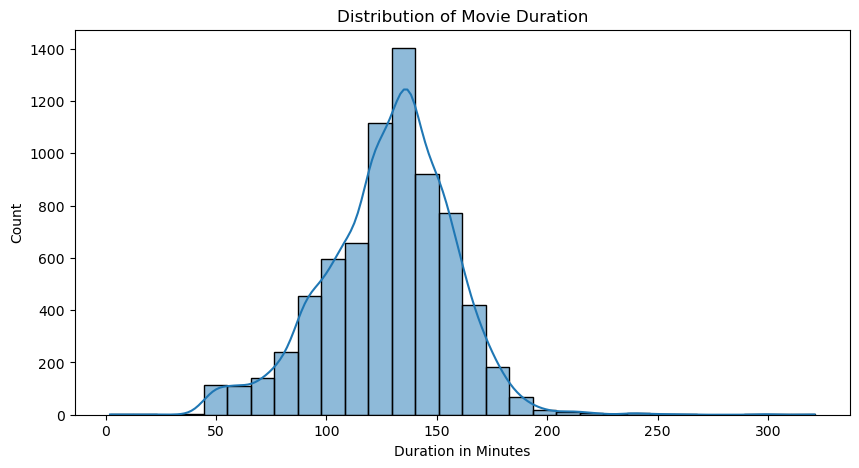

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eda["duration"], bins=30, kde=True)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration in Minutes")
plt.ylabel("Count")
plt.show()

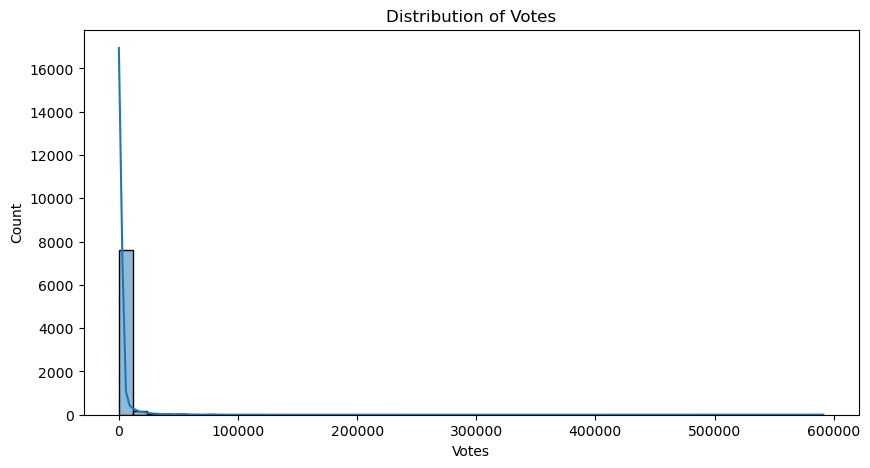

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eda["votes"], bins=50, kde=True)
plt.title("Distribution of Votes")
plt.xlabel("Votes")
plt.ylabel("Count")
plt.show()

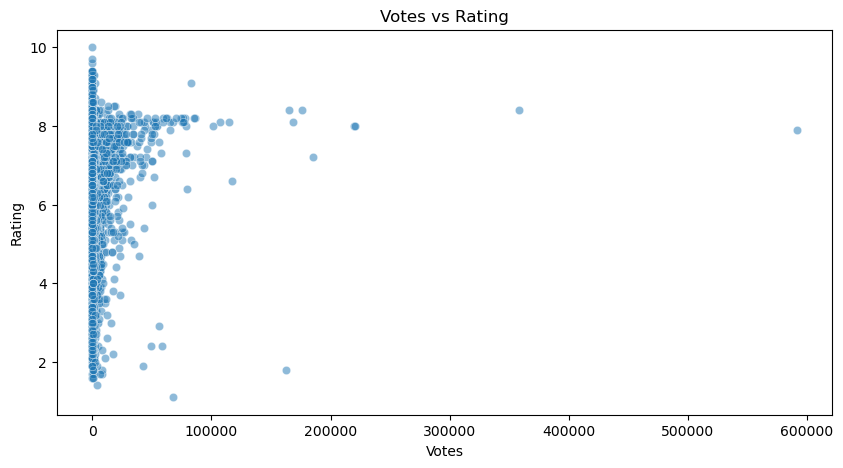

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_eda, x="votes", y="rating", alpha=0.5)
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

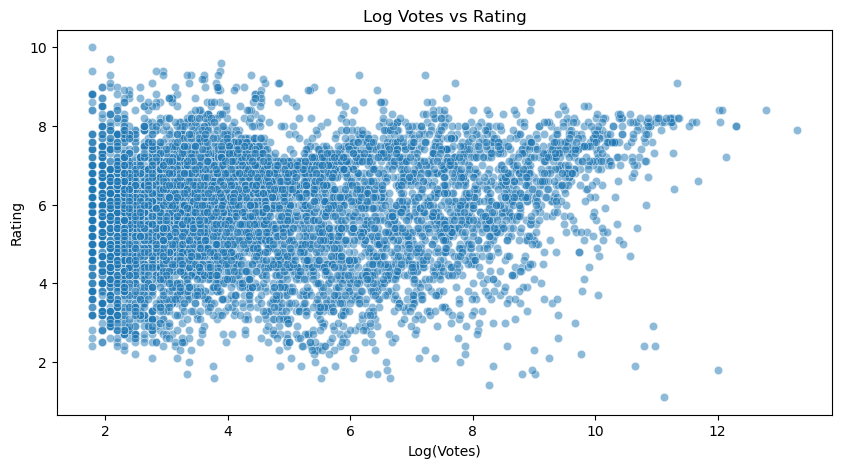

In [11]:
df_eda["log_votes"] = np.log1p(df_eda["votes"])

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_eda, x="log_votes", y="rating", alpha=0.5)
plt.title("Log Votes vs Rating")
plt.xlabel("Log(Votes)")
plt.ylabel("Rating")
plt.show()

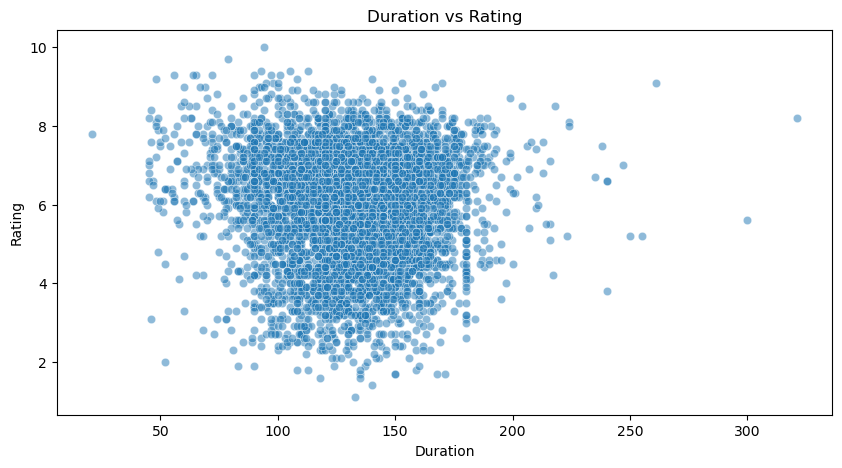

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_eda, x="duration", y="rating", alpha=0.5)
plt.title("Duration vs Rating")
plt.xlabel("Duration")
plt.ylabel("Rating")
plt.show()

In [13]:
df_eda["main_genre"] = df_eda["genre"].astype(str).str.split(",").str[0].str.strip()

display(df_eda[["name", "genre", "main_genre"]].head())

,name,genre,main_genre
0,,Drama,Drama
1,#Gadhvi (He thought he was Gandhi),Drama,Drama
2,#Homecoming,"Drama, Musical",Drama
3,#Yaaram,"Comedy, Romance",Comedy
4,...And Once Again,Drama,Drama


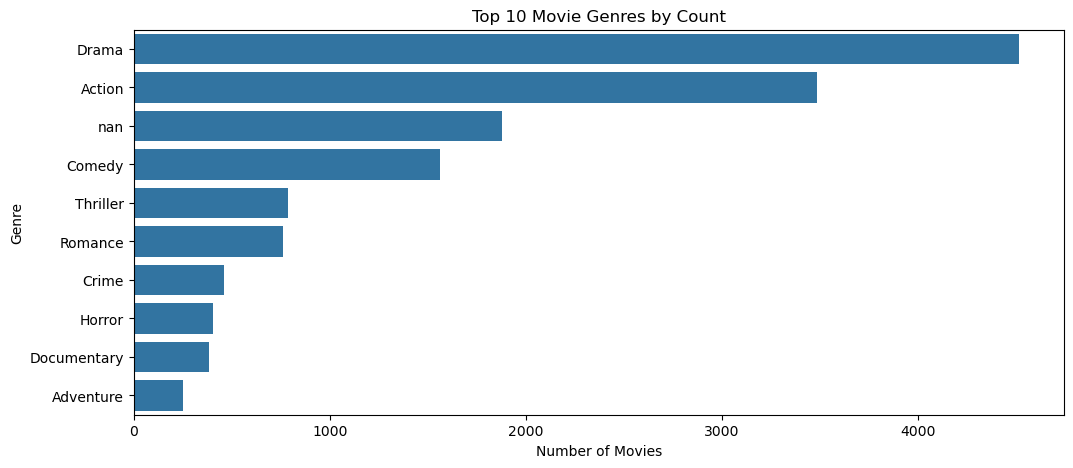

In [14]:
top_genres = df_eda["main_genre"].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Movie Genres by Count")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

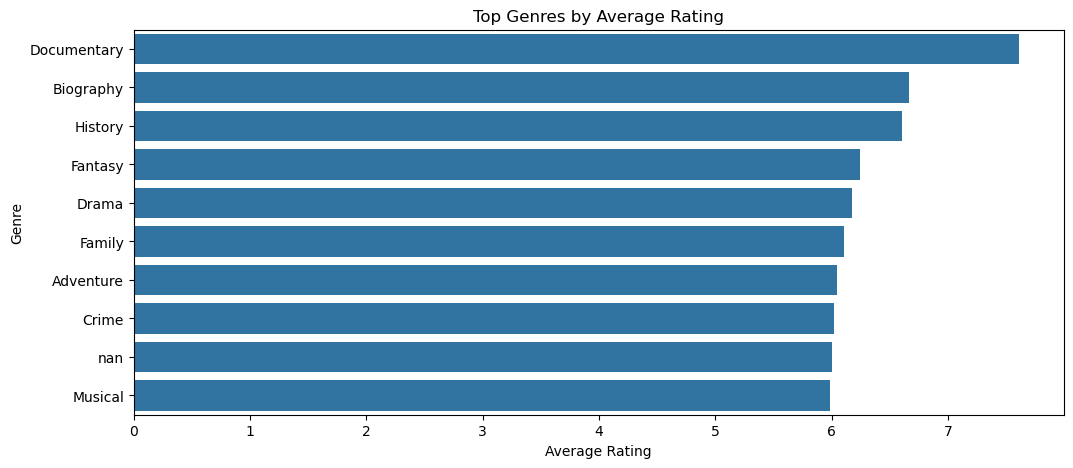

,count,mean
main_genre,,
Documentary,143,7.613287
Biography,99,6.666667
History,15,6.606667
Fantasy,52,6.246154
Drama,2532,6.172393
Family,85,6.107059
Adventure,160,6.048125
Crime,343,6.016327
nan,102,5.999020


In [15]:
genre_rating = (
    df_eda.groupby("main_genre")["rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

genre_rating = genre_rating[genre_rating["count"] >= 10].head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_rating["mean"], y=genre_rating.index)
plt.title("Top Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

display(genre_rating)

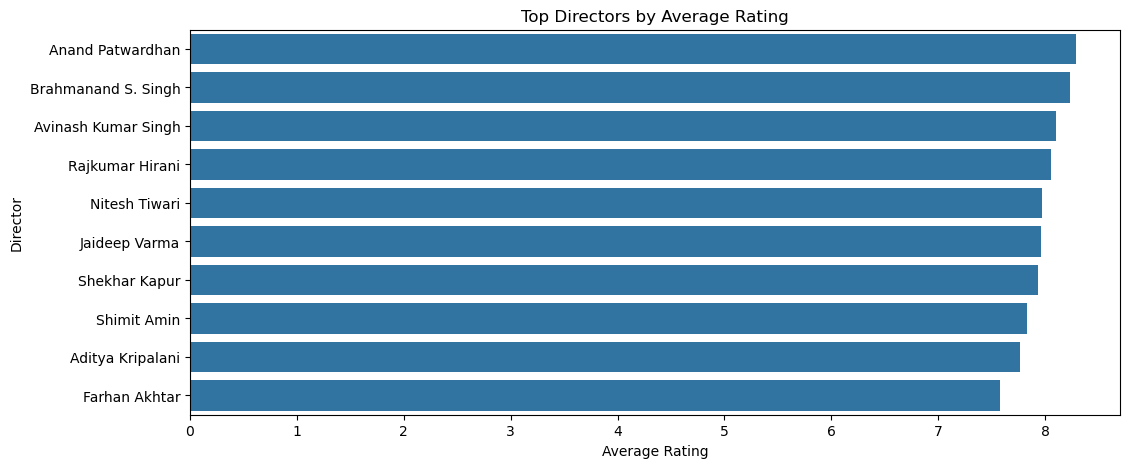

,count,mean
director,,
Anand Patwardhan,8,8.287500
Brahmanand S. Singh,3,8.233333
Avinash Kumar Singh,3,8.100000
Rajkumar Hirani,5,8.060000
Nitesh Tiwari,4,7.975000
Jaideep Varma,3,7.966667
Shekhar Kapur,3,7.933333
Shimit Amin,3,7.833333
Aditya Kripalani,3,7.766667


In [16]:
director_rating = (
    df_eda.groupby("director")["rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

top_directors = director_rating[director_rating["count"] >= 3].head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_directors["mean"], y=top_directors.index)
plt.title("Top Directors by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Director")
plt.show()

display(top_directors)

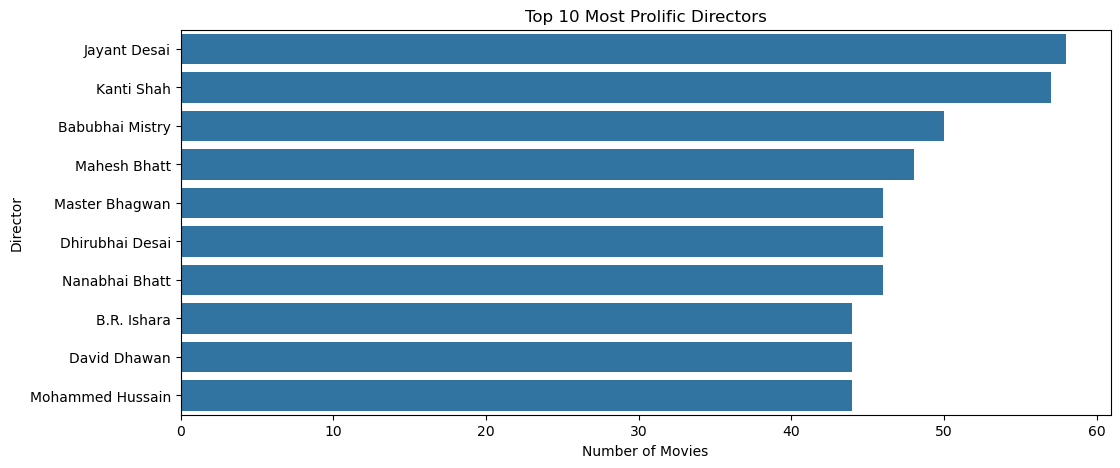

In [17]:
top_director_counts = df_eda["director"].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_director_counts.values, y=top_director_counts.index)
plt.title("Top 10 Most Prolific Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

In [18]:
df_eda["lead_actor"] = df_eda["actor_1"].astype(str).str.strip()

display(df_eda[["name", "lead_actor"]].head())

,name,lead_actor
0,,Manmauji
1,#Gadhvi (He thought he was Gandhi),Rasika Dugal
2,#Homecoming,Sayani Gupta
3,#Yaaram,Prateik
4,...And Once Again,Rajat Kapoor


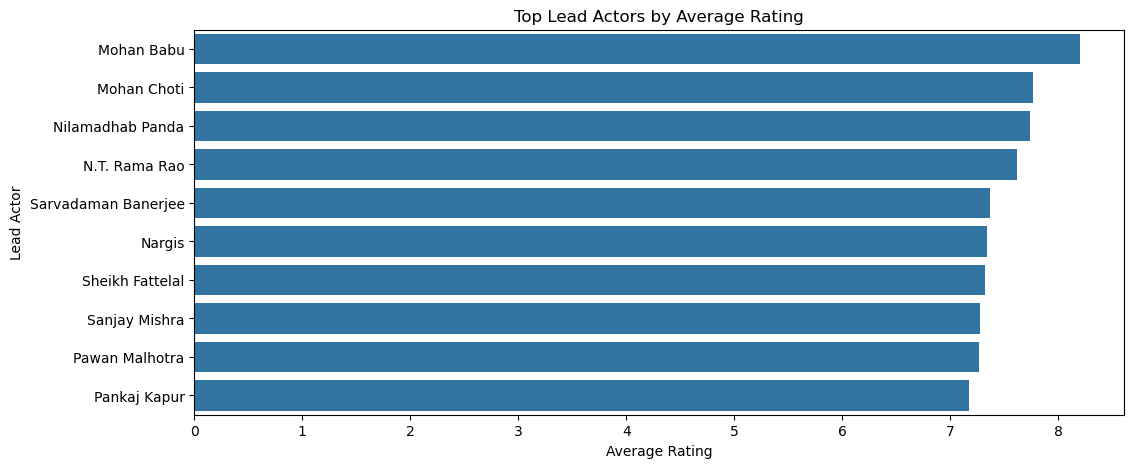

,count,mean
lead_actor,,
Mohan Babu,6,8.200000
Mohan Choti,3,7.766667
Nilamadhab Panda,3,7.733333
N.T. Rama Rao,7,7.614286
Sarvadaman Banerjee,3,7.366667
Nargis,27,7.340741
Sheikh Fattelal,4,7.325000
Sanjay Mishra,8,7.275000
Pawan Malhotra,3,7.266667


In [19]:
actor_rating = (
    df_eda.groupby("lead_actor")["rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

top_actors = actor_rating[actor_rating["count"] >= 3].head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_actors["mean"], y=top_actors.index)
plt.title("Top Lead Actors by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Lead Actor")
plt.show()

display(top_actors)

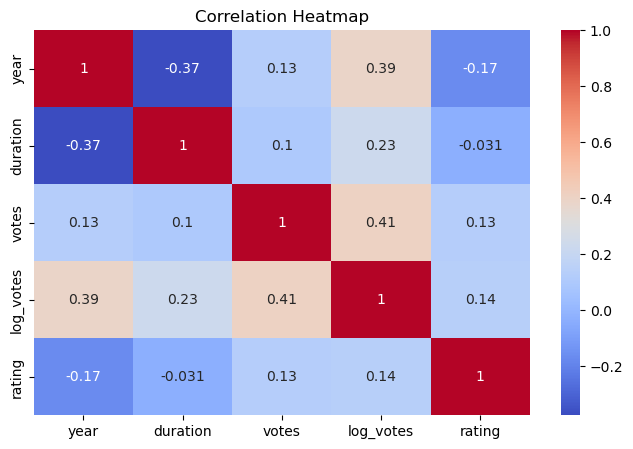

In [20]:
numeric_cols = ["year", "duration", "votes", "log_votes", "rating"]

plt.figure(figsize=(8, 5))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

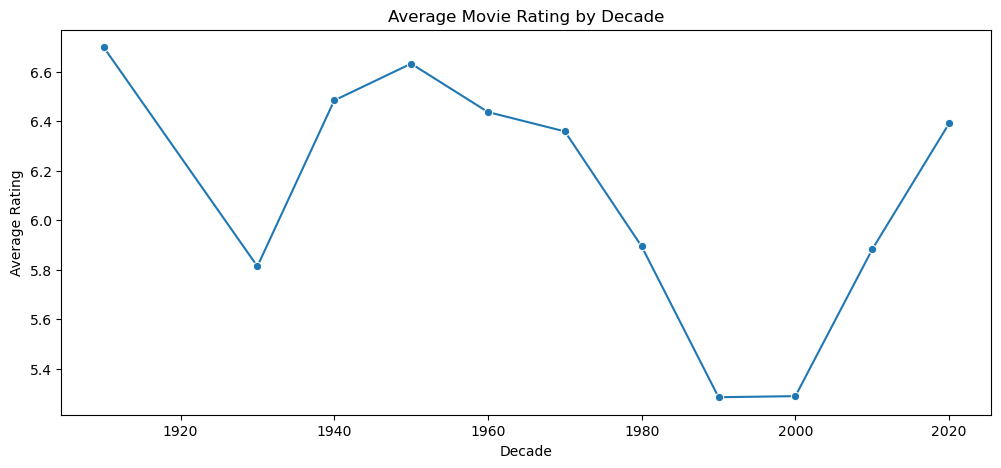

In [21]:
df_eda["decade"] = (df_eda["year"] // 10) * 10

decade_rating = df_eda.groupby("decade")["rating"].mean().dropna()

plt.figure(figsize=(12, 5))
sns.lineplot(x=decade_rating.index, y=decade_rating.values, marker="o")
plt.title("Average Movie Rating by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Rating")
plt.show()

In [22]:
df_eda.to_csv("../data/imdb_eda.csv", index=False)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!
